In [65]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
T, C, N, L, W = 100, 3, 3, 2, 1
K = N*L + W
T_sim = T + L

def companion(B, N, L):
    K = N * L
    C = np.zeros((K, K))
    C[:N, :] = B[:, :K]  # exclude w column
    C[N:, :-N] = np.eye(N * (L - 1))
    return C

betas = np.random.normal(0.2, 0.3, size=(C, N, K))
for c in range(C):
    comp = companion(betas[c], N, L)
    radius = np.max(np.abs(np.linalg.eigvals(comp)))
    if radius >= 1:
        betas[c] *= 0.8 / radius

gamma = np.zeros((C, N))
for c in range(C):
    gamma[c] = np.random.normal(c * 0.2 * (-1)**c, 0.1 + c * 0.05, size=N)

# innovations
innovations = np.zeros((T_sim, C, N))
for c in range(C):
    A = np.random.randn(N, N) * 0.1
    Sigma = A @ A.T + np.eye(N) * 0.01
    innovations[:, c, :] = np.random.multivariate_normal(np.zeros(N), Sigma, size=T_sim)

# exogenous variables
z = np.zeros(T_sim)
for t in range(1, T_sim):
    z[t] = 0.7*z[t-1] + np.random.randn()

w = np.zeros(T_sim)
for t in range(1, T_sim):
    w[t] = 0.3*w[t-1] + np.random.randn()

# simulate
Y = np.random.randn(T_sim, C, N)
for t in range(L, T_sim):
    for c in range(C):
        lags = np.concatenate([Y[t-1, c, :], Y[t-2, c, :], [w[t-1]]])
        Y[t, c, :] = betas[c] @ lags + gamma[c]*z[t-1] + innovations[t, c, :]

        
F = np.zeros((C, T, K+1))
for c in range(C):
    for t in range(L, T_sim):
        lags = np.concatenate([Y[t-1, c, :], Y[t-2, c, :], [w[t-1]]])
        X[c, t-L, :] = lags
        F[c, t-L, :] = np.concatenate([lags, [z[t-1]]])

Y = Y[L:, :, :]  # (T, C, N)
z = z[L:]
w = w[L:]
z = z.reshape(-1, 1)  # (T, 1)
ZZ = z.T @ z 
XX = np.array([X[c].T @ X[c] for c in range(C)])  # (C, NK, NK)
XZ = np.array([X[c].T @ z for c in range(C)])      # (C, NK, N_z)

In [ ]:
# Define relevant matrices

# block sizes
size_beta0 = N * K
size_betac = N * K
size_gammac = N
size_deltac = size_betac + size_gammac
size_delta = size_beta0 + C * size_deltac

# starting index of each block in delta
idx_beta0 = 0
idx_deltac = [size_beta0 + c * size_deltac for c in range(C)]  # start of delta_c
idx_betac  = [idx_deltac[c] for c in range(C)]                 # start of beta_c (same)
idx_gammac = [idx_deltac[c] + size_betac for c in range(C)]    # start of gamma_c

# selection matrices — S @ delta extracts the relevant block
def selection_matrix(size_delta, start, block_size):
    S = np.zeros((block_size, size_delta))
    S[:, start:start+block_size] = np.eye(block_size)
    return S

S0  = selection_matrix(size_delta, idx_beta0, size_beta0)   # (NK x len_delta)
S_beta  = [selection_matrix(size_delta, idx_betac[c],  size_betac)  for c in range(C)]
S_gamma = [selection_matrix(size_delta, idx_gammac[c], size_gammac) for c in range(C)]
S_delta = [selection_matrix(size_delta, idx_deltac[c], size_deltac) for c in range(C)]

Pc = np.zeros((size_deltac, size_deltac))

for n in range(N):
    for k in range(K):
        col_major_pos = k * N + n
        row_major_pos = n * K + k
        Pc[row_major_pos, col_major_pos] = 1

for i in range(N):
    Pc[N*K + i, N*K + i] = 1

Lambda = np.zeros((C, N*K, N*K))
for c in range(C):
    var_y = np.var(Y[:, c, :], axis=0)  # (N,)
    var_all = np.append(var_y, np.var(w))
    var_index = [n for l in range(L) for n in range(N)] + [N]
    
    diag = np.array([var_y[n] / var_all[var_index[k]] 
                     for n in range(N) for k in range(K)])
    Lambda[c] = np.diag(diag)

Lambda_inv = np.array([np.diag(1.0 / np.diag(Lambda[c])) for c in range(C)])
Lambda_inv_sum = np.sum(Lambda_inv, axis=0)

Big_S = np.zeros((size_delta, size_delta))
for c in range(C):
    diff = S_beta[c] - S0
    Big_S += diff.T @ Lambda_inv[c] @ diff

y = np.zeros((C, T*N))
for c in range(C):
    y[c] = Y[:, c, :].flatten(order='F')

In [68]:
# q(delta): N(mu_delta, V_delta)
mu_delta = np.zeros(size_delta)
V_delta  = np.eye(size_delta)

# q(lambda): we'll need shape and scale — initialise as vague
s_bar = C*N*K -1
v_bar = 0 + mu_delta.T @ Big_S @ mu_delta + np.trace(Big_S @ V_delta)
mu_lambda_inv = 1e4

# q(Sigma_c): inverse Wishart — initialise with identity
S_bar_sigma = [np.eye(N) * T for c in range(C)]
mu_sigma_inv = [np.linalg.inv(S_bar_sigma[c]) for c in range(C)]

In [ ]:
def calc_V_delta(mu_lambda_inv, mu_sigma_inv):
    total = mu_lambda_inv * Big_S
    for c in range(C):
        total += S_delta[c].T @ Pc.T @ np.kron(mu_sigma_inv[c], F[c].T @ F[c]) @ Pc @ S_delta[c]
    return np.linalg.inv(total)



def calc_V_delta_lw(mu_lambda_inv, mu_sigma_inv):
    total = mu_lambda_inv * Lambda_inv_sum
    for c in range(C):
        top_left = mu_lambda_inv * Lambda_inv[c] + np.kron(mu_sigma_inv[c], XX[c])
        top_right = np.kron(mu_sigma_inv[c], XZ[c])
        bottom_left = top_right.T
        bottom_right = np.kron(mu_sigma_inv[c], ZZ)

        H_c_inv = np.block([[top_left, top_right],[bottom_left, bottom_right]])
        H_c = np.linalg.inv(H_c_inv)

        total -= mu_lambda_inv**2 * (Lambda_inv[c] @ H_c[:size_beta_c, :size_beta_c] @ Lambda_inv[c])
    return np.linalg.inv(total)

def calc_mu_delta(V_delta, mu_sigma_inv):
    sum = 0
    for c in range(C):
        sum += S_delta[c].T @ Pc.T @ np.kron(mu_sigma_inv[c], F[c].T) @ y[c]
    return V_delta @ sum

def calc_S_bar_sigma(mu_delta, V_delta):
    S_bar_sigma = [np.eye(N)] * C
    for c in range(C):
        mu_deltac = S_delta[c] @ mu_delta
        vec_Gc = Pc @ mu_deltac
        mu_Gc = vec_Gc.reshape(K+1, N, order='F')

        M_c = Pc @ S_delta[c]
        FtF = F[c].T @ F[c]
        Omega_Gc = np.zeros((N, N))
        for i in range(N):
            for j in range(N):
                M_ci = M_c[i*(K+1):(i+1)*(K+1), :]
                M_cj = M_c[j*(K+1):(j+1)*(K+1), :]
                Omega_Gc[i, j] = np.trace(FtF @ M_ci @ V_delta @ M_cj.T)

        S_bar_sigma[c] = (Y[:, c, :] - F[c] @ mu_Gc).T @ (Y[:, c, :] - F[c] @ mu_Gc) + Omega_Gc
    return S_bar_sigma

def calc_ELBO(V_delta, s_bar, v_bar, S_bar_sigma):
    _, logdet_V = np.linalg.slogdet(V_delta)
    elbo = logdet_V - s_bar * np.log(v_bar) / 2
    for c in range(C):
        _, logdet_S = np.linalg.slogdet(S_bar_sigma[c])
        elbo -= T * logdet_S
    return elbo

In [70]:
epsilon = 1e-4
ELBO = []
while len(ELBO) < 10 or ELBO[-1] - ELBO[-2] > epsilon:
    V_delta = calc_V_delta(mu_lambda_inv, mu_sigma_inv)
    mu_delta = calc_mu_delta(V_delta, mu_sigma_inv)
    v_bar = mu_delta.T @ Big_S @ mu_delta + np.trace(Big_S @ V_delta)
    mu_lambda_inv = s_bar/v_bar
    S_bar_sigma = calc_S_bar_sigma(mu_delta, V_delta)
    mu_sigma_inv = [T * np.linalg.inv(S_bar_sigma[c]) for c in range(C)]
    ELBO.append(calc_ELBO(V_delta, s_bar, v_bar, S_bar_sigma))

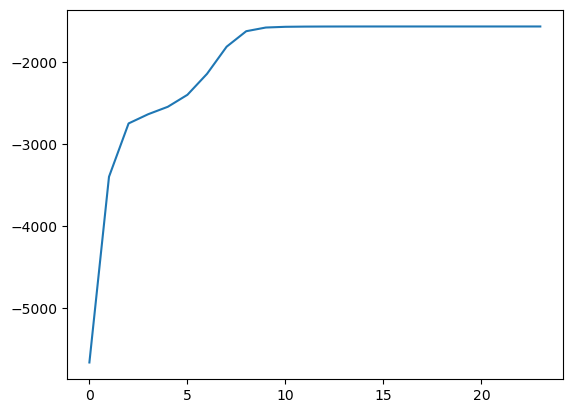

In [71]:
plt.plot(ELBO)

In [72]:
print(Y.min())
print(Y.max())

-5.179199235260619
6.033822902707394
